# Part A - Stage A - scarping

In [1]:
!pip install selenium
!pip install matplotlib
!pip install pandas
!pip install scikit-learn
!pip install seaborn

## Imports


In [2]:
# imports

import csv
import re
import time
import random
from dataclasses import asdict, dataclass
from datetime import date, timedelta, datetime

from selenium import webdriver
from selenium.common import InvalidSessionIdException, WebDriverException
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.chrome.service import Service

## Config


In [3]:
# Config

CITY = "New York"
ADULTS = 2
CHILDREN = 0
ROOMS = 1

TTT_RANGE = range(1, 31)
LOS_RANGE = range(1, 6)

HOTELS_PER_SEARCH = 100
PAGE_SIZE = 25
MAX_PAGES_GUARD = 10

## Data model


In [4]:
# Data model

@dataclass
class HotelRow:
    snapshot_date: str
    checkin: str
    checkout: str
    ttt: int
    los: int
    page_offset: int
    rank_in_search: int

    name: str
    price_raw: str
    review_score: str
    review_count: str
    stars: str
    distance: str
    room_type: str
    cancellation: str

    card_text: str
    url: str



## Selenium helpers


In [6]:
# Selenium helpers

from selenium import webdriver
from selenium.webdriver.chrome.options import Options

def build_driver(headless=False):
    opts = Options()
    if headless:
        opts.add_argument("--headless=new")

    opts.add_argument("--no-sandbox")
    opts.add_argument("--disable-dev-shm-usage")
    opts.add_argument("--disable-gpu")
    opts.add_argument("--window-size=1400,900")
    opts.add_argument("--remote-debugging-port=9222")
    opts.add_argument("--lang=en-US")

    return webdriver.Chrome(options=opts)


def ensure_driver(driver, headless=True):
    """If the driver session died, start a fresh driver."""
    if driver is None:
        return build_driver(headless=headless)
    try:
        _ = driver.current_url  # will throw if session is invalid
        return driver
    except (InvalidSessionIdException, WebDriverException):
        try:
            driver.quit()
        except Exception:
            pass
        return build_driver(headless=headless)


def safe_get(driver, url, headless=True, retries=2):
    """driver.get(url) but auto-recovers from a dead browser/session."""
    for i in range(retries + 1):
        driver = ensure_driver(driver, headless=headless)
        try:
            driver.get(url)
            return driver
        except (InvalidSessionIdException, WebDriverException):
            try:
                driver.quit()
            except Exception:
                pass
            driver = None
            time.sleep(2 + i)
    raise RuntimeError(f"Failed to load URL after retries: {url}")


def jitter_sleep(a=0.6, b=1.6):
    time.sleep(random.uniform(a, b))


def safe_text(el):
    try:
        return el.text.strip()
    except Exception:
        return ""


def first_match_text(parent, selectors):
    """
    selectors: list of tuples (By, value)
    returns first non-empty text
    """
    for by, val in selectors:
        try:
            el = parent.find_element(by, val)
            t = safe_text(el)
            if t:
                return t
        except Exception:
            continue
    return ""


def close_popups(driver):
    # Fast, non-blocking attempts only (no waits)

    # 1) Cookies
    cookie_selectors = [
        (By.ID, "onetrust-accept-btn-handler"),
        (By.CSS_SELECTOR, "button#onetrust-accept-btn-handler"),
        (By.XPATH, "//button[contains(., 'Accept')]"),
        (By.XPATH, "//button[contains(., 'I accept')]"),
        (By.XPATH, "//button[contains(., 'Agree')]"),
        (By.XPATH, "//button[contains(., 'Accept all')]"),
    ]
    for by, sel in cookie_selectors:
        try:
            els = driver.find_elements(by, sel)
            if els:
                els[0].click()
                return
        except Exception:
            pass

    # 2) Sign-in / app / modal close
    close_selectors = [
        (By.CSS_SELECTOR, "button[aria-label='Dismiss sign-in info.']"),
        (By.CSS_SELECTOR, "button[aria-label='Dismiss']"),
        (By.CSS_SELECTOR, "button[aria-label='Close']"),
        (By.CSS_SELECTOR, "button[aria-label='Close dialog']"),
        (By.CSS_SELECTOR, "button.modal-mask-closeBtn"),
        (By.CSS_SELECTOR, "button[data-testid='close-icon']"),
        (By.CSS_SELECTOR, "button[data-testid='popover-dismiss']"),
    ]
    for by, sel in close_selectors:
        try:
            els = driver.find_elements(by, sel)
            if els:
                els[0].click()
                return
        except Exception:
            pass


## CSV writing


In [7]:
def ensure_csv_header(path: str, fieldnames):
    try:
        with open(path, "r", encoding="utf-8") as _:
            return
    except FileNotFoundError:
        with open(path, "w", newline="", encoding="utf-8") as f:
            w = csv.DictWriter(f, fieldnames=fieldnames)
            w.writeheader()


def append_rows(path: str, rows):
    if not rows:
        return
    fieldnames = list(asdict(rows[0]).keys())
    ensure_csv_header(path, fieldnames)
    with open(path, "a", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        for r in rows:
            w.writerow(asdict(r))


## Booking helpers


In [8]:
BOOKING_BASE_URL = "https://www.booking.com/searchresults.html"


def build_search_url(checkin: date, checkout: date, offset: int) -> str:
    params = {
        "ss": CITY,
        "checkin": checkin.isoformat(),
        "checkout": checkout.isoformat(),
        "group_adults": str(ADULTS),
        "group_children": str(CHILDREN),
        "no_rooms": str(ROOMS),
        "offset": str(offset),
        "lang": "en-us",
        "selected_currency": "USD",
    }
    qp = "&".join([f"{k}={v}".replace(" ", "%20") for k, v in params.items()])
    return f"{BOOKING_BASE_URL}?{qp}"


def parse_stars_from_card(card) -> str:
    """
    Booking often encodes stars in aria-label, e.g. "4 out of 5"
    """
    try:
        star_els = card.find_elements(By.CSS_SELECTOR, "[aria-label*='out of 5']")
        for el in star_els:
            al = el.get_attribute("aria-label") or ""
            m = re.search(r"(\d)\s*out of 5", al)
            if m:
                return m.group(1)
    except Exception:
        pass
    return ""


def parse_hotel_card(card, snapshot_date: str, checkin: date, checkout: date,
                     ttt: int, los: int, offset: int, rank: int) -> HotelRow:
    try:
        a = card.find_element(By.CSS_SELECTOR, "a[data-testid='title-link']")
        url = a.get_attribute("href") or ""
    except Exception:
        pass

    name = first_match_text(card, [
        (By.CSS_SELECTOR, "[data-testid='title']"),
        (By.CSS_SELECTOR, "div[data-testid='title']"),
    ])

    # Price (often includes currency sign)
    price_raw = first_match_text(card, [
        (By.CSS_SELECTOR, "[data-testid='price-and-discounted-price']"),
        (By.CSS_SELECTOR, "span[data-testid='price-and-discounted-price']"),
    ])

    # Review score + count
    review_score = ""
    review_count = ""
    try:
        score_wrap = card.find_element(By.CSS_SELECTOR, "[data-testid='review-score']")
        # Usually contains score + label + "X reviews"
        txt = score_wrap.text.strip()
        # score is often first token like "8.6"
        m = re.search(r"(\d+(?:\.\d+)?)", txt)
        if m:
            review_score = m.group(1)
        # review count
        m2 = re.search(r"([\d,]+)\s+reviews", txt, re.IGNORECASE)
        if m2:
            review_count = m2.group(1).replace(",", "")
    except Exception:
        pass

    stars = parse_stars_from_card(card)

    # Distance (often "X km from center")
    distance = first_match_text(card, [
        (By.CSS_SELECTOR, "[data-testid='distance']"),
        (By.XPATH, ".//*[contains(text(),'from center')]"),
    ])

    # Room type / bed info sometimes appear as short lines
    room_type = first_match_text(card, [
        (By.CSS_SELECTOR, "[data-testid='recommended-units']"),
        (By.XPATH, ".//*[contains(text(),'bed')]"),
    ])

    # Cancellation / prepayment lines
    cancellation = first_match_text(card, [
        (By.XPATH, ".//*[contains(translate(., 'FREECANCELATION', 'freecancelation'), 'free cancellation')]"),
        (By.XPATH, ".//*[contains(translate(., 'NOPREPAYMENT', 'noprepayment'), 'no prepayment')]"),
        (By.XPATH, ".//*[contains(translate(., 'CANCELLATION', 'cancellation'), 'cancellation')]"),
    ])

    card_text = card.text.strip()

    return HotelRow(
        snapshot_date=snapshot_date,
        checkin=checkin.isoformat(),
        checkout=checkout.isoformat(),
        ttt=ttt,
        los=los,
        page_offset=offset,
        rank_in_search=rank,

        name=name,
        price_raw=price_raw,
        review_score=review_score,
        review_count=review_count,
        stars=stars,
        distance=distance,
        room_type=room_type,
        cancellation=cancellation,

        card_text=card_text,
        url=url
    )

## Scraping logic


In [9]:
def scrape_one_search(driver, snapshot_date: str, checkin: date, checkout: date, ttt: int, los: int, headless:bool):
    collected = []
    rank = 0

    for page_i in range(MAX_PAGES_GUARD):
        offset = page_i * PAGE_SIZE
        url = build_search_url(checkin, checkout, offset)
        driver = safe_get(driver, url, headless=headless)

        close_popups(driver)

        # Wait for results list to appear
        WebDriverWait(driver, 25).until(
            EC.presence_of_all_elements_located((By.CSS_SELECTOR, "div[data-testid='property-card']"))
        )
        jitter_sleep(0.2, 0.6)

        cards = driver.find_elements(By.CSS_SELECTOR, "div[data-testid='property-card']")
        if not cards:
            close_popups(driver)
            break

        for card in cards:
            rank += 1
            row = parse_hotel_card(
                card=card,
                snapshot_date=snapshot_date,
                checkin=checkin,
                checkout=checkout,
                ttt=ttt,
                los=los,
                offset=offset,
                rank=rank,
            )
            collected.append(row)

            if len(collected) >= HOTELS_PER_SEARCH:
                return collected

        # If we reached end (no next page), break
        # Heuristic: if less than PAGE_SIZE cards, often last page.
        if len(cards) < max(10, PAGE_SIZE // 2):
            break
        close_popups(driver)
        jitter_sleep(0.7, 1.4)

    return collected

## Run 


In [10]:
def run_snapshot(snapshot_label: str, base_today: date = None, headless: bool = True):
    """
    snapshot_label: saved to CSV to mark the run.
    base_today: optional override; by default uses today's date.
    """
    if base_today is None:
        base_today = date.today()
    output_csv = f"booking_nyc_{datetime.now().strftime('%Y-%m-%d_%H-%M')}.csv"
    driver = build_driver(headless=headless)
    try:
        for ttt in TTT_RANGE:
            for los in LOS_RANGE:
                checkin = base_today + timedelta(days=ttt)
                checkout = checkin + timedelta(days=los)

                print(f"[{snapshot_label}] TTT={ttt} LOS={los} | {checkin} -> {checkout}")
                rows = scrape_one_search(driver, snapshot_label, checkin, checkout, ttt, los, headless)

                # Save immediately (so if it crashes you keep progress)
                append_rows(output_csv, rows)
                print(f"  saved {len(rows)} hotels")

                # Gentle pacing
                jitter_sleep(2.0, 4.0)
    finally:
        driver.quit()

## Run (Notebook)
Run the next cell to start a snapshot from this notebook.

In [18]:
run_snapshot(snapshot_label=datetime.now().date().isoformat(), headless=False)


[2026-01-26] TTT=1 LOS=1 | 2026-01-27 -> 2026-01-28
  saved 100 hotels
[2026-01-26] TTT=1 LOS=2 | 2026-01-27 -> 2026-01-29
  saved 100 hotels
[2026-01-26] TTT=1 LOS=3 | 2026-01-27 -> 2026-01-30
  saved 100 hotels
[2026-01-26] TTT=1 LOS=4 | 2026-01-27 -> 2026-01-31


KeyboardInterrupt: 

# Part A — Stage B: Exploration & Data Preprocessing

- Plot distributions of: **review counts**, **review scores**, **prices**
- Remove price outliers using **Tukey (1.5 × IQR)**
- Encode **ordinal** variables (e.g., review labels / bed types) into ordered numbers
- Encode **nominal/categorical** variables using **one-hot encoding**
- Show a **seaborn PairGrid** and briefly interpret relationships (especially with the target: **price**)

In [7]:
# Step 1: Load the scraped CSVs

import glob
import pandas as pd
import numpy as np
import re

CSV_FILES = sorted(glob.glob("booking_nyc_*.csv"))

print("Detected CSV files:", CSV_FILES)

df = pd.concat([pd.read_csv(p) for p in CSV_FILES], ignore_index=True) if CSV_FILES else pd.DataFrame()
print("Rows:", len(df), "| Columns:", list(df.columns))
df.head()

Detected CSV files: ['booking_nyc_2026-01-23_16-14.csv', 'booking_nyc_2026-01-24_15-23.csv', 'booking_nyc_2026-01-28_16-10.csv']
Rows: 45000 | Columns: ['snapshot_date', 'checkin', 'checkout', 'ttt', 'los', 'page_offset', 'rank_in_search', 'name', 'price_raw', 'review_score', 'review_count', 'stars', 'distance', 'room_type', 'cancellation', 'card_text', 'url']


,snapshot_date,checkin,checkout,ttt,los,page_offset,rank_in_search,name,price_raw,review_score,review_count,stars,distance,room_type,cancellation,card_text,url
0,2026-01-23,2026-01-24,2026-01-25,1,1,0,1,The Historic Blue Moon Hotel - NYC,US$242,7.9,193.0,4.0,5.5 km from downtown,Pied - a - Terre with Shared Balcony\n1 king b...,The Historic Blue Moon Hotel - NYC\nOpens in n...,The Historic Blue Moon Hotel - NYC\nOpens in n...,https://www.booking.com/hotel/us/blue-moon-pow...
1,2026-01-23,2026-01-24,2026-01-25,1,1,0,2,Newly Renovated Rooms at Club Quarters Hotel T...,US$197,8.3,2325.0,4.0,1.3 km from downtown,Newly Renovated Club Room\n1 queen bed\nNo pre...,Newly Renovated Rooms at Club Quarters Hotel T...,Newly Renovated Rooms at Club Quarters Hotel T...,https://www.booking.com/hotel/us/club-quarters...
2,2026-01-23,2026-01-24,2026-01-25,1,1,0,3,Grayson Hotel,US$209,8.5,1510.0,4.0,1.8 km from downtown,King Room\n1 king bed\nNo prepayment needed – ...,Grayson Hotel\nOpens in new window\nFeatured\n...,Grayson Hotel\nOpens in new window\nFeatured\n...,https://www.booking.com/hotel/us/grayson-new-y...
3,2026-01-23,2026-01-24,2026-01-25,1,1,0,4,Margaritaville Resort Times Square,US$226,8.5,5034.0,4.0,1.5 km from downtown,Standard Room one queen Bed\n1 queen bed,NaN,Margaritaville Resort Times Square\nOpens in n...,https://www.booking.com/hotel/us/margaritavill...
4,2026-01-23,2026-01-24,2026-01-25,1,1,0,5,Motto by Hilton New York City Chelsea,US$192,8.7,2835.0,4.0,2.8 km from downtown,King Room\n1 king bed\nNo prepayment needed – ...,Motto by Hilton New York City Chelsea\nOpens i...,Motto by Hilton New York City Chelsea\nOpens i...,https://www.booking.com/hotel/us/motto-by-hilt...


In [8]:
# Step 2: Basic cleaning + parsing numeric fields

def parse_price_to_usd(price_raw: str):
    if pd.isna(price_raw):
        return np.nan
    s = str(price_raw)
    # Keep digits and separators, then extract a number (handles "$1,234" etc.)
    m = re.search(r"(\d[\d,\.\s]*)", s)
    if not m:
        return np.nan
    num = m.group(1).replace(",", "").replace(" ", "")
    try:
        return float(num)
    except Exception:
        return np.nan

def parse_int(x):
    try:
        if pd.isna(x): 
            return np.nan
        s = str(x).strip().replace(",", "")
        return int(float(s))
    except Exception:
        return np.nan

def parse_float(x):
    try:
        if pd.isna(x): 
            return np.nan
        s = str(x).strip()
        return float(s)
    except Exception:
        return np.nan

def parse_distance_km(distance_text: str):
    if pd.isna(distance_text):
        return np.nan
    s = str(distance_text).lower()
    # Examples: "1.2 km from center", "0.7 miles from center"
    m = re.search(r"(\d+(?:\.\d+)?)\s*(km|kilometers|miles|mi)", s)
    if not m:
        return np.nan
    val = float(m.group(1))
    unit = m.group(2)
    if unit in ("miles", "mi"):
        return val * 1.60934
    return val

if df.empty:
    print("No data loaded. Please set CSV_FILES or adjust the glob pattern above.")
else:
    df = df.copy()

    # Parse numeric columns we will use later
    df["price_usd"] = df["price_raw"].apply(parse_price_to_usd)
    df["review_score_num"] = df["review_score"].apply(parse_float)
    df["review_count_num"] = df["review_count"].apply(parse_int)
    df["stars_num"] = df["stars"].apply(parse_int)
    df["distance_km"] = df["distance"].apply(parse_distance_km)

    # Remove obvious empty rows
    df = df.dropna(subset=["name"], how="any")

    print(df[["price_raw","price_usd","review_score","review_score_num","review_count","review_count_num","stars","stars_num","distance","distance_km"]].head(10))
    print("Missing price_usd:", df["price_usd"].isna().mean().round(3))

  price_raw  price_usd  review_score  review_score_num  review_count  \
0    US$242      242.0           7.9               7.9         193.0   
1    US$197      197.0           8.3               8.3        2325.0   
2    US$209      209.0           8.5               8.5        1510.0   
3    US$226      226.0           8.5               8.5        5034.0   
4    US$192      192.0           8.7               8.7        2835.0   
5    US$178      178.0           7.9               7.9        1602.0   
6    US$204      204.0           8.1               8.1        1411.0   
7    US$243      243.0           8.4               8.4       12573.0   
8    US$234      234.0           8.6               8.6        3508.0   
9    US$171      171.0           8.1               8.1        2252.0   

   review_count_num  stars  stars_num              distance  distance_km  
0             193.0    4.0        4.0  5.5 km from downtown          5.5  
1            2325.0    4.0        4.0  1.3 km from downto

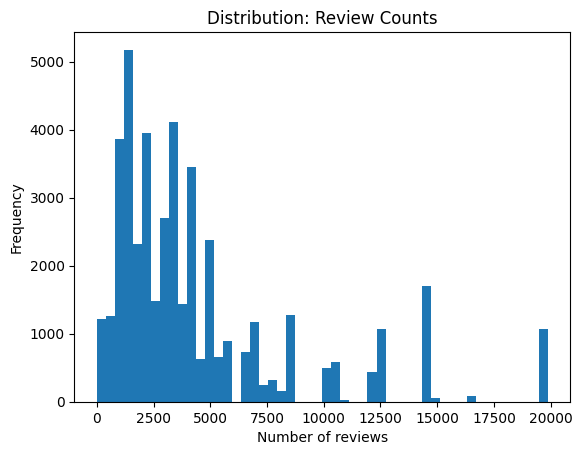

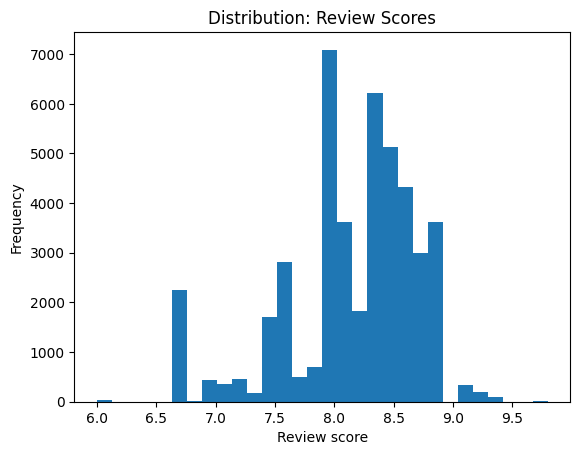

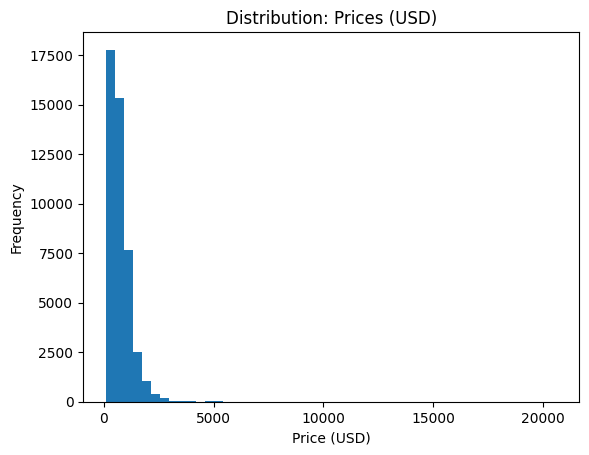

In [9]:
# Step 3: Distributions (review count, review score, prices)

import matplotlib.pyplot as plt

if not df.empty:
    # Review count
    plt.figure()
    df["review_count_num"].dropna().plot(kind="hist", bins=50)
    plt.title("Distribution: Review Counts")
    plt.xlabel("Number of reviews")
    plt.ylabel("Frequency")
    plt.show()

    # Review score
    plt.figure()
    df["review_score_num"].dropna().plot(kind="hist", bins=30)
    plt.title("Distribution: Review Scores")
    plt.xlabel("Review score")
    plt.ylabel("Frequency")
    plt.show()

    # Price (raw)
    plt.figure()
    df["price_usd"].dropna().plot(kind="hist", bins=50)
    plt.title("Distribution: Prices (USD)")
    plt.xlabel("Price (USD)")
    plt.ylabel("Frequency")
    plt.show()
else:
    print("df is empty.")

In [10]:
# Step 4: Remove price outliers (Tukey 1.5 * IQR)

def tukey_filter(series: pd.Series, k: float = 1.5):
    s = series.dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - k * iqr
    hi = q3 + k * iqr
    return lo, hi

if not df.empty:
    lo, hi = tukey_filter(df["price_usd"], k=1.5)
    print("Tukey bounds for price_usd:", lo, hi)

    before = len(df)
    df_no_out = df[(df["price_usd"].isna()) | ((df["price_usd"] >= lo) & (df["price_usd"] <= hi))].copy()
    after = len(df_no_out)

    print(f"Rows before: {before} | after: {after} | removed: {before-after}")
    df_no_out[["price_usd","review_score_num","review_count_num","stars_num","distance_km"]].describe()
else:
    df_no_out = df

Tukey bounds for price_usd: -532.0 1812.0
Rows before: 45000 | after: 43605 | removed: 1395


# Ordinal encoding

We convert **ordered** (ordinal) categories to numbers.

Examples:
- Review label (e.g., *Good < Very Good < Excellent*) — if such labels appear in your scraped text.
- Bed/room type — we build a **distinct list** and map to an ordered scale (e.g., *Single < Twin < Double < Queen < King*).

In [11]:
# Step 5: Ordinal encoding (review label + bed type)

import pandas as pd
import numpy as np
import re

def extract_review_label(card_text: str):
    if pd.isna(card_text):
        return ""
    s = str(card_text).lower()
    # Common Booking labels
    for lbl in ["exceptional", "wonderful", "fabulous", "very good", "good", "pleasant", "okay", "poor"]:
        if lbl in s:
            return lbl
    return ""

# Ordered mapping (lowest -> highest)
review_label_order = ["poor", "okay", "pleasant", "good", "very good", "fabulous", "wonderful", "exceptional"]
review_label_to_num = {lbl: i for i, lbl in enumerate(review_label_order, start=1)}

def bed_type_from_room(room_type: str):
    if pd.isna(room_type):
        return ""
    s = str(room_type).lower()
    # Pick the "strongest" match
    if "king" in s: return "king"
    if "queen" in s: return "queen"
    if "double" in s: return "double"
    if "twin" in s: return "twin"
    if "single" in s: return "single"
    return ""

bed_order = ["single", "twin", "double", "queen", "king"]
bed_to_num = {b:i for i,b in enumerate(bed_order, start=1)}

if not df_no_out.empty:
    df_no_out["review_label"] = df_no_out["card_text"].apply(extract_review_label)
    df_no_out["review_label_ord"] = df_no_out["review_label"].map(review_label_to_num).astype("Float64")

    df_no_out["bed_type"] = df_no_out["room_type"].apply(bed_type_from_room)
    # Distinct list of bed types (required by the instructions)
    distinct_beds = sorted([b for b in df_no_out["bed_type"].dropna().unique() if b])
    print("Distinct bed types found:", distinct_beds)

    df_no_out["bed_type_ord"] = df_no_out["bed_type"].map(bed_to_num).astype("Float64")

    df_no_out[["review_label","review_label_ord","room_type","bed_type","bed_type_ord"]].head(12)
else:
    print("df_no_out is empty.")

Distinct bed types found: ['double', 'king', 'queen', 'single', 'twin']


## Nominal / categorical encoding (One-Hot)

We convert **non-ordered** categories to one-hot columns (e.g., cancellation/prepayment).  
For neighborhood, we try to extract a coarse area from `card_text` when possible

In [12]:
# Step 6: Nominal encoding (cancellation / prepayment / neighborhood)

from sklearn.preprocessing import OneHotEncoder

def cancellation_category(cancellation_text: str):
    if pd.isna(cancellation_text):
        return "unknown"
    s = str(cancellation_text).lower()
    if "free cancellation" in s:
        return "free_cancellation"
    if "no prepayment" in s:
        return "no_prepayment"
    if "cancellation" in s:
        return "cancellation_policy"
    return "other"

# Very coarse neighborhood extraction attempt (works only if area names appear in card_text)
NEIGHBORHOODS = [
    "manhattan", "brooklyn", "queens", "bronx", "staten island",
    "times square", "midtown", "uptown", "downtown", "soho", "chelsea", "harlem"
]
def extract_neighborhood(card_text: str):
    if pd.isna(card_text):
        return "unknown"
    s = str(card_text).lower()
    for n in NEIGHBORHOODS:
        if n in s:
            return n
    return "unknown"

if not df_no_out.empty:
    df_no_out["cancellation_cat"] = df_no_out["cancellation"].apply(cancellation_category)
    df_no_out["neighborhood"] = df_no_out["card_text"].apply(extract_neighborhood)

    cat_cols = ["cancellation_cat", "neighborhood"]
    enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

    X_cat = enc.fit_transform(df_no_out[cat_cols])
    cat_feature_names = enc.get_feature_names_out(cat_cols)

    df_cat = pd.DataFrame(X_cat, columns=cat_feature_names, index=df_no_out.index)

    # Combine with numeric/ordinal features for later analysis
    feature_df = pd.concat(
        [
            df_no_out[["price_usd","review_score_num","review_count_num","stars_num","distance_km","ttt","los","review_label_ord","bed_type_ord"]].copy(),
            df_cat
        ],
        axis=1
    )

    print("Feature table shape:", feature_df.shape)
    feature_df.head()
else:
    feature_df = pd.DataFrame()
    print("df_no_out is empty.")

Feature table shape: (43605, 16)


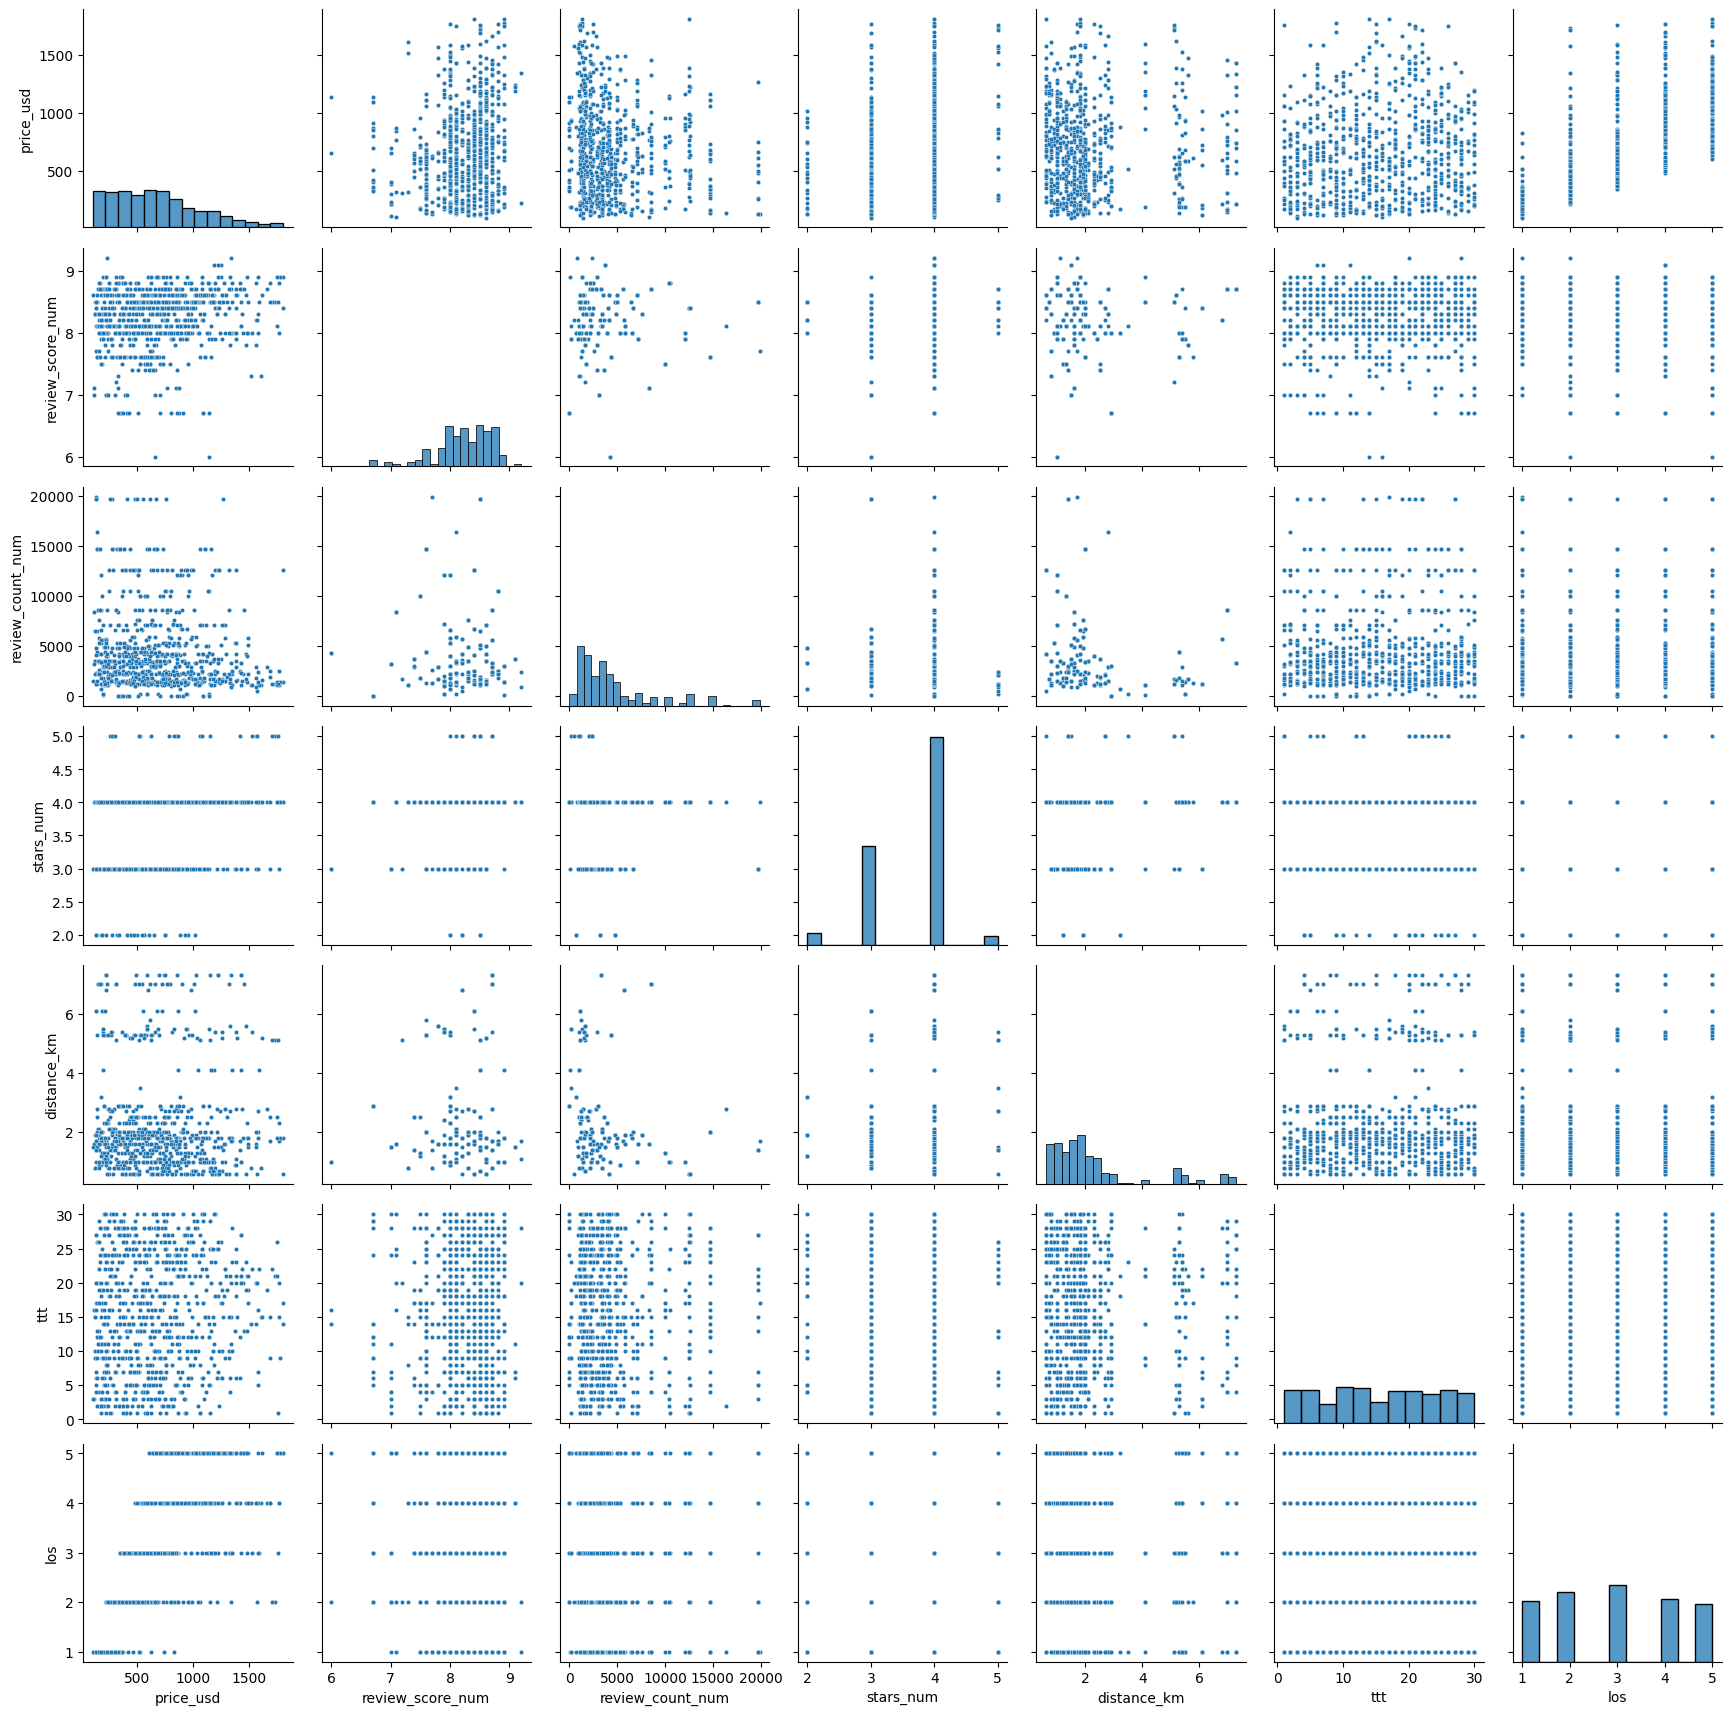

In [13]:
# Step 7: PairGrid

import seaborn as sns
import matplotlib.pyplot as plt

if not feature_df.empty:
    # Pick a compact set of columns for visualization
    cols = ["price_usd", "review_score_num", "review_count_num", "stars_num", "distance_km", "ttt", "los"]
    viz = feature_df[cols].dropna().sample(min(800, len(feature_df)), random_state=7)

    g = sns.PairGrid(viz)
    g.map_diag(sns.histplot)
    g.map_offdiag(sns.scatterplot, s=10)
    plt.show()
else:
    print("feature_df is empty.")

# Stage C: Price Prediction


In [14]:
# Task 1: Build X, y (final modeling table)

import pandas as pd
import numpy as np

assert "feature_df" in globals(), "feature_df was not found. Run Stage B cells first."

df_model = feature_df.copy()

# Target
TARGET_COL = "price_usd"
assert TARGET_COL in df_model.columns, f"{TARGET_COL} is missing from feature_df."

# Keep only numeric features (feature_df should already be numeric + one-hot + ordinal)
# Drop rows where target is missing
df_model = df_model.dropna(subset=[TARGET_COL]).copy()

# Basic cleanup: replace inf with NaN
df_model = df_model.replace([np.inf, -np.inf], np.nan)

# Separate X/y
y = df_model[TARGET_COL].astype(float)
X = df_model.drop(columns=[TARGET_COL])

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Any NaNs in X? ->", X.isna().any().any())
print("Target summary:")
display(y.describe())


X shape: (43605, 15)
y shape: (43605,)
Any NaNs in X? -> True
Target summary:


count    43605.000000
mean       650.888247
std        383.147200
min         86.000000
25%        338.000000
50%        597.000000
75%        892.000000
max       1811.000000
Name: price_usd, dtype: float64

In [15]:
# Task 2: Simple imputation
# all features are numeric, so median imputation is safe.

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

print("After imputation - Any NaNs in X? ->", X_imputed.isna().any().any())
X_imputed.head()


After imputation - Any NaNs in X? -> False


,review_score_num,review_count_num,stars_num,distance_km,ttt,los,review_label_ord,bed_type_ord,cancellation_cat_free_cancellation,cancellation_cat_no_prepayment,cancellation_cat_unknown,neighborhood_downtown,neighborhood_manhattan,neighborhood_midtown,neighborhood_times square
0,7.9,193.0,4.0,5.5,1.0,1.0,4.0,5.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,8.3,2325.0,4.0,1.3,1.0,1.0,5.0,4.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,8.5,1510.0,4.0,1.8,1.0,1.0,5.0,5.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,8.5,5034.0,4.0,1.5,1.0,1.0,5.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,8.7,2835.0,4.0,2.8,1.0,1.0,5.0,5.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [16]:
# Task 3: Train/Test split (70/30)

from sklearn.model_selection import train_test_split

RANDOM_STATE = 7

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.30, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, y_train.shape)
print("Test: ", X_test.shape, y_test.shape)


Train: (30523, 15) (30523,)
Test:  (13082, 15) (13082,)


# Task 4: Three additional regression models (not taught in class)
In this section we train and evaluate three regressors:

RandomForestRegressor

GradientBoostingRegressor

SVR (SVM regression) with feature scaling

For each model we report: R², MAE, MSE, RMSE on both train and test, and we plot a residual plot on the test set.

In [17]:
# Common evaluation helpers

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def regression_metrics(y_true, y_pred):
    r2  = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return {"R2": r2, "MAE": mae, "MSE": mse, "RMSE": rmse}

def residual_plot(y_true, y_pred, title):
    resid = y_true - y_pred
    plt.figure()
    plt.scatter(y_pred, resid, s=10)
    plt.axhline(0)
    plt.title(title)
    plt.xlabel("Predicted price (USD)")
    plt.ylabel("Residual (true - pred)")
    plt.show()

def fit_predict_evaluate(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    pred_tr = model.predict(X_train)
    pred_te = model.predict(X_test)

    m_tr = regression_metrics(y_train, pred_tr)
    m_te = regression_metrics(y_test, pred_te)
    return m_tr, m_te, pred_te


# RandomForestRegressor

Random Forest is an ensemble of decision trees.
It usually performs well on tabular data without requiring feature scaling.

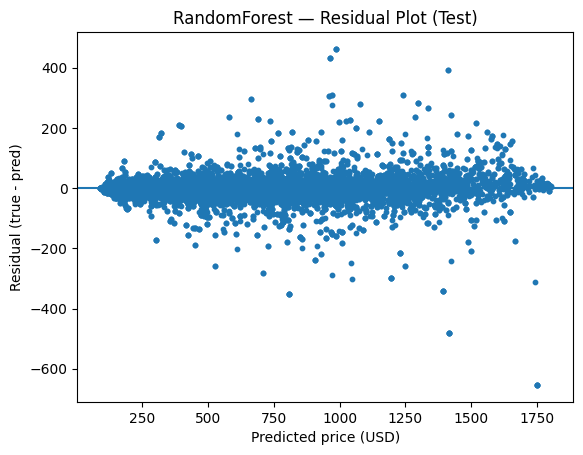

,model,train_R2,train_MAE,train_MSE,train_RMSE,test_R2,test_MAE,test_MSE,test_RMSE
0,RandomForest,0.995667,12.430681,640.948148,25.316954,0.987617,20.988771,1784.974191,42.248955


In [18]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=7,
    n_jobs=-1
)

rf_train_metrics, rf_test_metrics, rf_pred_test = fit_predict_evaluate(
    rf, X_train, y_train, X_test, y_test
)

residual_plot(y_test, rf_pred_test, "RandomForest — Residual Plot (Test)")

rf_row = {
    "model": "RandomForest",
    **{f"train_{k}": v for k, v in rf_train_metrics.items()},
    **{f"test_{k}": v for k, v in rf_test_metrics.items()},
}
pd.DataFrame([rf_row])


# GradientBoostingRegressor

Gradient Boosting builds trees sequentially, where each tree corrects the errors of the previous ones.
It often achieves strong performance on structured/tabular datasets.

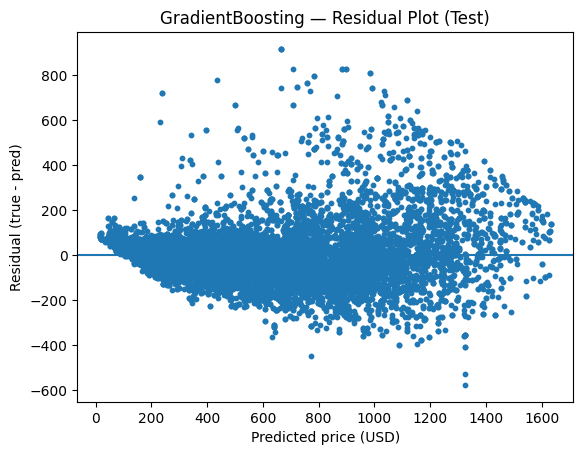

,model,train_R2,train_MAE,train_MSE,train_RMSE,test_R2,test_MAE,test_MSE,test_RMSE
0,GradientBoosting,0.886812,87.130532,16743.226554,129.39562,0.884988,87.209418,16578.170848,128.756246


In [19]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=3,
    random_state=7
)

gb_train_metrics, gb_test_metrics, gb_pred_test = fit_predict_evaluate(
    gb, X_train, y_train, X_test, y_test
)

residual_plot(y_test, gb_pred_test, "GradientBoosting — Residual Plot (Test)")

gb_row = {
    "model": "GradientBoosting",
    **{f"train_{k}": v for k, v in gb_train_metrics.items()},
    **{f"test_{k}": v for k, v in gb_test_metrics.items()},
}
pd.DataFrame([gb_row])


# SVR (Support Vector Regression)

SVR is sensitive to feature scales, so we use StandardScaler in a pipeline.
SVR can be slow on large datasets, so we optionally subsample the training set for speed.

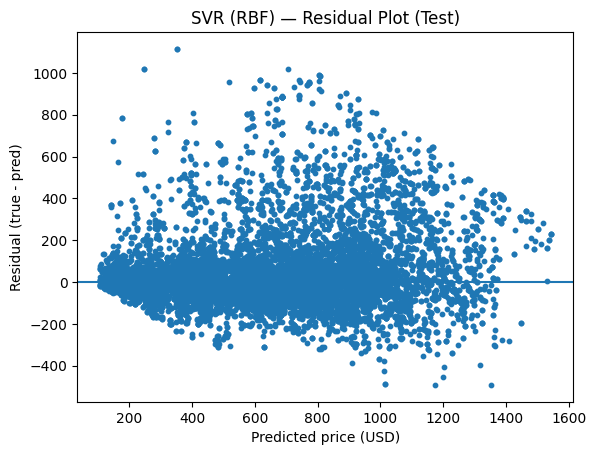

,model,train_R2,train_MAE,train_MSE,train_RMSE,test_R2,test_MAE,test_MSE,test_RMSE
0,SVR (RBF),0.780579,105.016845,32491.713875,180.254581,0.78146,106.242009,31500.950363,177.485071


In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

SVR_TRAIN_SAMPLES = 8000  # set to None to use the full training set

if SVR_TRAIN_SAMPLES is not None and len(X_train) > SVR_TRAIN_SAMPLES:
    idx = np.random.RandomState(7).choice(len(X_train), size=SVR_TRAIN_SAMPLES, replace=False)
    X_train_svr = X_train.iloc[idx]
    y_train_svr = y_train.iloc[idx]
else:
    X_train_svr = X_train
    y_train_svr = y_train

svr = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(C=30.0, epsilon=0.1, kernel="rbf", gamma="scale"))
])

svr_train_metrics, svr_test_metrics, svr_pred_test = fit_predict_evaluate(
    svr, X_train_svr, y_train_svr, X_test, y_test
)

residual_plot(y_test, svr_pred_test, "SVR (RBF) — Residual Plot (Test)")

svr_row = {
    "model": "SVR (RBF)",
    **{f"train_{k}": v for k, v in svr_train_metrics.items()},
    **{f"test_{k}": v for k, v in svr_test_metrics.items()},
}
pd.DataFrame([svr_row])


In [21]:
results_df = pd.DataFrame([rf_row, gb_row, svr_row])
results_df

,model,train_R2,train_MAE,train_MSE,train_RMSE,test_R2,test_MAE,test_MSE,test_RMSE
0,RandomForest,0.995667,12.430681,640.948148,25.316954,0.987617,20.988771,1784.974191,42.248955
1,GradientBoosting,0.886812,87.130532,16743.226554,129.395620,0.884988,87.209418,16578.170848,128.756246
2,SVR (RBF),0.780579,105.016845,32491.713875,180.254581,0.781460,106.242009,31500.950363,177.485071


# Task 5 

In this task we experiment with different hyperparameters for our models and compare performance on the test set.
We report R², MAE, MSE, RMSE and select the best configuration per model.

In [22]:
import numpy as np
import pandas as pd

def run_experiments(model_name, configs, build_model_fn, X_train, y_train, X_test, y_test):
    rows = []
    for cfg in configs:
        model = build_model_fn(cfg)
        tr_m, te_m, _ = fit_predict_evaluate(model, X_train, y_train, X_test, y_test)

        rows.append({
            "model": model_name,
            **cfg,
            **{f"train_{k}": v for k, v in tr_m.items()},
            **{f"test_{k}": v for k, v in te_m.items()},
        })
    return pd.DataFrame(rows).sort_values("test_RMSE")


# RandomForest hyperparameters

We vary key RandomForest parameters:

n_estimators (number of trees)

max_depth (tree depth)

min_samples_leaf (leaf size)

max_features (feature sampling per split)

In [23]:
from sklearn.ensemble import RandomForestRegressor

rf_configs = [
    {"n_estimators": 200, "max_depth": None, "min_samples_leaf": 2, "max_features": "sqrt"},
    {"n_estimators": 400, "max_depth": None, "min_samples_leaf": 2, "max_features": "sqrt"},
    {"n_estimators": 400, "max_depth": 20,  "min_samples_leaf": 2, "max_features": "sqrt"},
    {"n_estimators": 400, "max_depth": 20,  "min_samples_leaf": 5, "max_features": "sqrt"},
    {"n_estimators": 400, "max_depth": 12,  "min_samples_leaf": 5, "max_features": "sqrt"},
    {"n_estimators": 600, "max_depth": 20,  "min_samples_leaf": 3, "max_features": "sqrt"},
]

def build_rf(cfg):
    return RandomForestRegressor(
        n_estimators=cfg["n_estimators"],
        max_depth=cfg["max_depth"],
        min_samples_leaf=cfg["min_samples_leaf"],
        max_features=cfg["max_features"],
        random_state=7,
        n_jobs=-1
    )

rf_exp = run_experiments("RandomForest", rf_configs, build_rf, X_train, y_train, X_test, y_test)
rf_exp


,model,n_estimators,max_depth,min_samples_leaf,max_features,train_R2,train_MAE,train_MSE,train_RMSE,test_R2,test_MAE,test_MSE,test_RMSE
0,RandomForest,200,NaN,2,sqrt,0.993331,18.173648,986.513697,31.408816,0.985345,26.122780,2112.426266,45.961139
1,RandomForest,400,NaN,2,sqrt,0.993364,18.070991,981.611158,31.330674,0.985323,26.111820,2115.557297,45.995188
2,RandomForest,400,20.0,2,sqrt,0.992684,19.595343,1082.172989,32.896398,0.984458,27.290752,2240.337124,47.332200
5,RandomForest,600,20.0,3,sqrt,0.980469,33.533191,2889.156220,53.750872,0.970576,40.236161,4241.219168,65.124643
3,RandomForest,400,20.0,5,sqrt,0.958260,50.195178,6174.363528,78.577118,0.949134,55.099876,7331.941315,85.626756
4,RandomForest,400,12.0,5,sqrt,0.909648,78.214183,13365.252271,115.608184,0.902416,80.472682,14066.009161,118.600207


# GradientBoosting hyperparameters

We experiment with:

n_estimators

learning_rate

max_depth

In [24]:
from sklearn.ensemble import GradientBoostingRegressor

gb_configs = [
    {"n_estimators": 300, "learning_rate": 0.05, "max_depth": 2},
    {"n_estimators": 500, "learning_rate": 0.05, "max_depth": 2},
    {"n_estimators": 500, "learning_rate": 0.05, "max_depth": 3},
    {"n_estimators": 800, "learning_rate": 0.03, "max_depth": 3},
    {"n_estimators": 800, "learning_rate": 0.05, "max_depth": 3},
    {"n_estimators": 1200,"learning_rate": 0.03, "max_depth": 3},
]

def build_gb(cfg):
    return GradientBoostingRegressor(
        n_estimators=cfg["n_estimators"],
        learning_rate=cfg["learning_rate"],
        max_depth=cfg["max_depth"],
        random_state=7
    )

gb_exp = run_experiments("GradientBoosting", gb_configs, build_gb, X_train, y_train, X_test, y_test)
gb_exp


,model,n_estimators,learning_rate,max_depth,train_R2,train_MAE,train_MSE,train_RMSE,test_R2,test_MAE,test_MSE,test_RMSE
4,GradientBoosting,800,0.05,3,0.909418,77.522790,13399.183692,115.754843,0.906323,78.057293,13502.821608,116.201642
5,GradientBoosting,1200,0.03,3,0.906333,79.102824,13855.652815,117.710037,0.903241,79.710581,13947.128418,118.097961
2,GradientBoosting,500,0.05,3,0.894160,84.309799,15656.311092,125.125182,0.892054,84.449773,15559.640942,124.738290
3,GradientBoosting,800,0.03,3,0.892114,84.918245,15958.890427,126.328502,0.889994,85.053453,15856.499684,125.922594
1,GradientBoosting,500,0.05,2,0.848287,102.471388,22441.948806,149.806371,0.845848,102.715770,22219.904384,149.063424
0,GradientBoosting,300,0.05,2,0.828886,108.782792,25311.867550,159.097038,0.826778,108.947207,24968.756494,158.015051


# SVR hyperparameters

SVR is sensitive to scaling and can be slow.
We vary:

C

epsilon

(kernel fixed to RBF)

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

# Use the same SVR train subset we already defined 
X_tr = X_train_svr if "X_train_svr" in globals() else X_train
y_tr = y_train_svr if "y_train_svr" in globals() else y_train

svr_configs = [
    {"C": 10.0,  "epsilon": 0.10},
    {"C": 30.0,  "epsilon": 0.10},
    {"C": 50.0,  "epsilon": 0.10},
    {"C": 30.0,  "epsilon": 0.20},
    {"C": 50.0,  "epsilon": 0.20},
    {"C": 100.0, "epsilon": 0.20},
]

def build_svr(cfg):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(C=cfg["C"], epsilon=cfg["epsilon"], kernel="rbf", gamma="scale"))
    ])

svr_exp = run_experiments("SVR_RBF", svr_configs, build_svr, X_tr, y_tr, X_test, y_test)
svr_exp


,model,C,epsilon,train_R2,train_MAE,train_MSE,train_RMSE,test_R2,test_MAE,test_MSE,test_RMSE
5,SVR_RBF,100.0,0.2,0.820182,92.106974,26627.227122,163.178513,0.820038,94.438875,25940.212950,161.059656
4,SVR_RBF,50.0,0.2,0.799382,99.144097,29707.390556,172.358320,0.800662,100.592270,28733.092567,169.508385
2,SVR_RBF,50.0,0.1,0.799383,99.143770,29707.229639,172.357853,0.800661,100.595148,28733.220030,169.508761
3,SVR_RBF,30.0,0.2,0.780598,105.017897,32488.827882,180.246575,0.781482,106.241642,31497.771132,177.476114
1,SVR_RBF,30.0,0.1,0.780579,105.016845,32491.713875,180.254581,0.781460,106.242009,31500.950363,177.485071
0,SVR_RBF,10.0,0.1,0.728027,120.517746,40273.464289,200.682496,0.730207,120.847712,38888.658055,197.202074


pick the best configuration

In [26]:
best_rf  = rf_exp.iloc[0]
best_gb  = gb_exp.iloc[0]
best_svr = svr_exp.iloc[0]

best_summary = pd.DataFrame([best_rf, best_gb, best_svr])
best_summary[["model","test_R2","test_MAE","test_RMSE"] + [c for c in best_summary.columns if c in ["n_estimators","max_depth","min_samples_leaf","max_features","learning_rate","C","epsilon"]]]


,model,test_R2,test_MAE,test_RMSE,n_estimators,max_depth,min_samples_leaf,max_features,learning_rate,C,epsilon
0,RandomForest,0.985345,26.122780,45.961139,200.0,NaN,2.0,sqrt,NaN,NaN,NaN
4,GradientBoosting,0.906323,78.057293,116.201642,800.0,3.0,NaN,NaN,0.05,NaN,NaN
5,SVR_RBF,0.820038,94.438875,161.059656,NaN,NaN,NaN,NaN,NaN,100.0,0.2


# Task 6

In this task we create additional engineered features that may improve price prediction.
We then rebuild the modeling table and compare model performance before vs. after feature engineering.

In [27]:
# Create engineered features (from dates + transformations)

import pandas as pd
import numpy as np

assert "df_no_out" in globals(), "df_no_out not found. Run Stage B first."

df_fe = df_no_out.copy()

# Parse check-in date (stored as ISO string)
df_fe["checkin_dt"] = pd.to_datetime(df_fe["checkin"], errors="coerce")

# Day-of-week features
# Monday=0 ... Sunday=6
df_fe["checkin_weekday"] = df_fe["checkin_dt"].dt.weekday

# Weekend check-in flag (Fri/Sat/Sun are often pricier in many cities)
df_fe["is_weekend_checkin"] = df_fe["checkin_weekday"].isin([4, 5, 6]).astype(int)

# Calendar features
df_fe["checkin_month"] = df_fe["checkin_dt"].dt.month
df_fe["checkin_day"] = df_fe["checkin_dt"].dt.day

# Nonlinear transformation: review counts are heavy-tailed
df_fe["log_review_count"] = np.log1p(df_fe["review_count_num"])

df_fe[["checkin","checkin_weekday","is_weekend_checkin","checkin_month","checkin_day","review_count_num","log_review_count"]].head()


,checkin,checkin_weekday,is_weekend_checkin,checkin_month,checkin_day,review_count_num,log_review_count
0,2026-01-24,5,1,1,24,193.0,5.267858
1,2026-01-24,5,1,1,24,2325.0,7.751905
2,2026-01-24,5,1,1,24,1510.0,7.320527
3,2026-01-24,5,1,1,24,5034.0,8.524169
4,2026-01-24,5,1,1,24,2835.0,7.950150


In [28]:
# Rebuild feature_df_fe (numeric + ordinal + one-hot + engineered)

from sklearn.preprocessing import OneHotEncoder

# Ensure ordinal & categorical columns exist (Stage B logic)
def extract_review_label(card_text: str):
    if pd.isna(card_text):
        return ""
    s = str(card_text).lower()
    for lbl in ["exceptional", "wonderful", "fabulous", "very good", "good", "pleasant", "okay", "poor"]:
        if lbl in s:
            return lbl
    return ""

review_label_order = ["poor", "okay", "pleasant", "good", "very good", "fabulous", "wonderful", "exceptional"]
review_label_to_num = {lbl: i for i, lbl in enumerate(review_label_order, start=1)}

def bed_type_from_room(room_type: str):
    if pd.isna(room_type):
        return ""
    s = str(room_type).lower()
    if "king" in s: return "king"
    if "queen" in s: return "queen"
    if "double" in s: return "double"
    if "twin" in s: return "twin"
    if "single" in s: return "single"
    return ""

bed_order = ["single", "twin", "double", "queen", "king"]
bed_to_num = {b:i for i,b in enumerate(bed_order, start=1)}

def cancellation_category(cancellation_text: str):
    if pd.isna(cancellation_text):
        return "unknown"
    s = str(cancellation_text).lower()
    if "free cancellation" in s:
        return "free_cancellation"
    if "no prepayment" in s:
        return "no_prepayment"
    if "cancellation" in s:
        return "cancellation_policy"
    return "other"

NEIGHBORHOODS = [
    "manhattan", "brooklyn", "queens", "bronx", "staten island",
    "times square", "midtown", "uptown", "downtown", "soho", "chelsea", "harlem"
]
def extract_neighborhood(card_text: str):
    if pd.isna(card_text):
        return "unknown"
    s = str(card_text).lower()
    for n in NEIGHBORHOODS:
        if n in s:
            return n
    return "unknown"

df_fe["review_label"] = df_fe["card_text"].apply(extract_review_label)
df_fe["review_label_ord"] = df_fe["review_label"].map(review_label_to_num).astype("Float64")

df_fe["bed_type"] = df_fe["room_type"].apply(bed_type_from_room)
df_fe["bed_type_ord"] = df_fe["bed_type"].map(bed_to_num).astype("Float64")

df_fe["cancellation_cat"] = df_fe["cancellation"].apply(cancellation_category)
df_fe["neighborhood"] = df_fe["card_text"].apply(extract_neighborhood)

cat_cols = ["cancellation_cat", "neighborhood"]
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_cat = enc.fit_transform(df_fe[cat_cols])
cat_feature_names = enc.get_feature_names_out(cat_cols)
df_cat = pd.DataFrame(X_cat, columns=cat_feature_names, index=df_fe.index)

# Numeric + ordinal + engineered
base_numeric = ["price_usd","review_score_num","review_count_num","stars_num","distance_km","ttt","los","review_label_ord","bed_type_ord"]
engineered = ["checkin_weekday","is_weekend_checkin","checkin_month","checkin_day","log_review_count"]

feature_df_fe = pd.concat(
    [
        df_fe[base_numeric + engineered].copy(),
        df_cat
    ],
    axis=1
)

print("feature_df_fe shape:", feature_df_fe.shape)
feature_df_fe.head()


feature_df_fe shape: (43605, 21)


,price_usd,review_score_num,review_count_num,stars_num,distance_km,ttt,los,review_label_ord,bed_type_ord,checkin_weekday,...,checkin_month,checkin_day,log_review_count,cancellation_cat_free_cancellation,cancellation_cat_no_prepayment,cancellation_cat_unknown,neighborhood_downtown,neighborhood_manhattan,neighborhood_midtown,neighborhood_times square
0,242.0,7.9,193.0,4.0,5.5,1,1,4.0,5.0,5,...,1,24,5.267858,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,197.0,8.3,2325.0,4.0,1.3,1,1,5.0,4.0,5,...,1,24,7.751905,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,209.0,8.5,1510.0,4.0,1.8,1,1,5.0,5.0,5,...,1,24,7.320527,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,226.0,8.5,5034.0,4.0,1.5,1,1,5.0,4.0,5,...,1,24,8.524169,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,192.0,8.7,2835.0,4.0,2.8,1,1,<NA>,5.0,5,...,1,24,7.950150,0.0,1.0,0.0,1.0,0.0,0.0,0.0


In [29]:
# Rebuild Train/Test split using engineered features

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

TARGET_COL = "price_usd"
df_model_fe = feature_df_fe.dropna(subset=[TARGET_COL]).replace([np.inf, -np.inf], np.nan).copy()

y_fe = df_model_fe[TARGET_COL].astype(float)
X_fe = df_model_fe.drop(columns=[TARGET_COL])

imputer_fe = SimpleImputer(strategy="median")
X_fe_imp = pd.DataFrame(imputer_fe.fit_transform(X_fe), columns=X_fe.columns, index=X_fe.index)

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe_imp, y_fe, test_size=0.30, random_state=7
)

print("Train (FE):", X_train_fe.shape, y_train_fe.shape)
print("Test  (FE):", X_test_fe.shape, y_test_fe.shape)


Train (FE): (30523, 20) (30523,)
Test  (FE): (13082, 20) (13082,)


RandomForest comparison

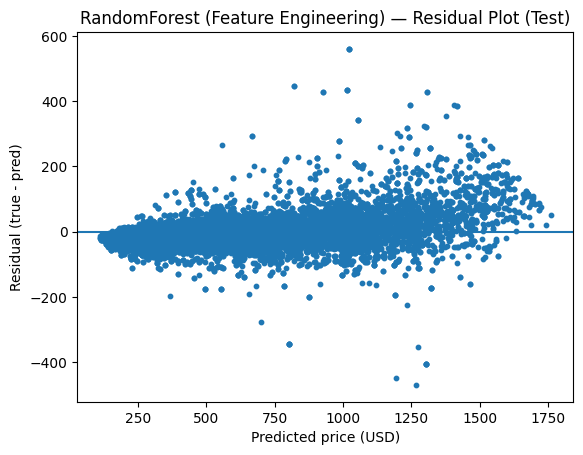

,model,train_R2,train_MAE,train_MSE,train_RMSE,test_R2,test_MAE,test_MSE,test_RMSE
0,RandomForest_FE,0.988355,26.578312,1722.565203,41.503797,0.98045,33.849723,2818.060823,53.085411


In [30]:
from sklearn.ensemble import RandomForestRegressor

rf_fe = RandomForestRegressor(
    n_estimators=400,
    max_depth=20,
    min_samples_leaf=3,
    max_features="sqrt",
    random_state=7,
    n_jobs=-1
)

rf_train_m_fe, rf_test_m_fe, rf_pred_test_fe = fit_predict_evaluate(
    rf_fe, X_train_fe, y_train_fe, X_test_fe, y_test_fe
)

residual_plot(y_test_fe, rf_pred_test_fe, "RandomForest (Feature Engineering) — Residual Plot (Test)")

rf_fe_row = {
    "model": "RandomForest_FE",
    **{f"train_{k}": v for k, v in rf_train_m_fe.items()},
    **{f"test_{k}": v for k, v in rf_test_m_fe.items()},
}
pd.DataFrame([rf_fe_row])


GradientBoosting

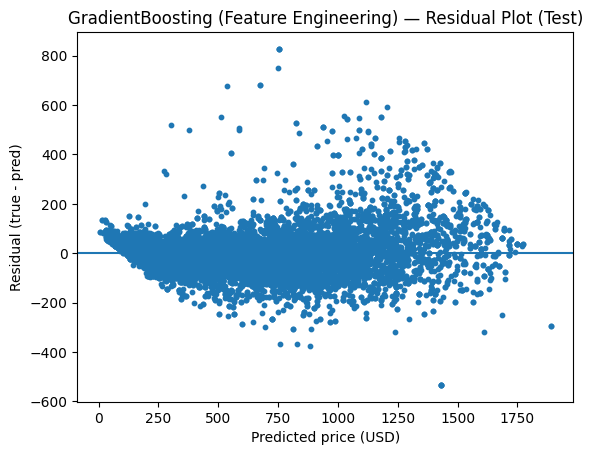

,model,train_R2,train_MAE,train_MSE,train_RMSE,test_R2,test_MAE,test_MSE,test_RMSE
0,GradientBoosting_FE,0.951435,56.231992,7183.881951,84.757784,0.950655,56.183052,7112.675797,84.336681


In [31]:
from sklearn.ensemble import GradientBoostingRegressor

gb_fe = GradientBoostingRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=3,
    random_state=7
)

gb_train_m_fe, gb_test_m_fe, gb_pred_test_fe = fit_predict_evaluate(
    gb_fe, X_train_fe, y_train_fe, X_test_fe, y_test_fe
)

residual_plot(y_test_fe, gb_pred_test_fe, "GradientBoosting (Feature Engineering) — Residual Plot (Test)")

gb_fe_row = {
    "model": "GradientBoosting_FE",
    **{f"train_{k}": v for k, v in gb_train_m_fe.items()},
    **{f"test_{k}": v for k, v in gb_test_m_fe.items()},
}
pd.DataFrame([gb_fe_row])


SVR

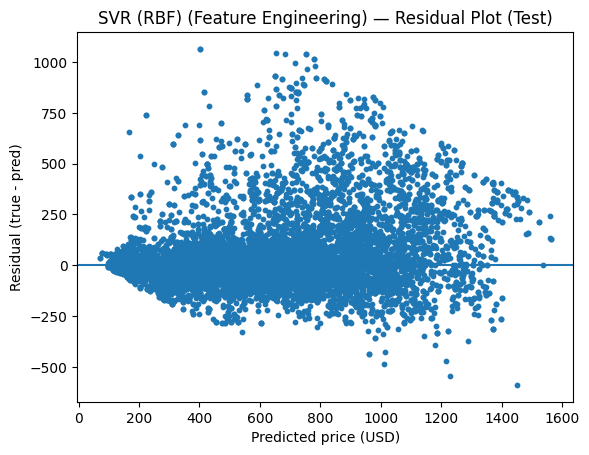

,model,train_R2,train_MAE,train_MSE,train_RMSE,test_R2,test_MAE,test_MSE,test_RMSE
0,SVR_FE,0.799271,98.054671,29723.762701,172.405808,0.799078,100.368917,28961.398114,170.180487


In [32]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

SVR_TRAIN_SAMPLES = 8000  # set to None to use full training set

if SVR_TRAIN_SAMPLES is not None and len(X_train_fe) > SVR_TRAIN_SAMPLES:
    idx = np.random.RandomState(7).choice(len(X_train_fe), size=SVR_TRAIN_SAMPLES, replace=False)
    X_train_fe_svr = X_train_fe.iloc[idx]
    y_train_fe_svr = y_train_fe.iloc[idx]
else:
    X_train_fe_svr = X_train_fe
    y_train_fe_svr = y_train_fe

svr_fe = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(C=30.0, epsilon=0.1, kernel="rbf", gamma="scale"))
])

svr_train_m_fe, svr_test_m_fe, svr_pred_test_fe = fit_predict_evaluate(
    svr_fe, X_train_fe_svr, y_train_fe_svr, X_test_fe, y_test_fe
)

residual_plot(y_test_fe, svr_pred_test_fe, "SVR (RBF) (Feature Engineering) — Residual Plot (Test)")

svr_fe_row = {
    "model": "SVR_FE",
    **{f"train_{k}": v for k, v in svr_train_m_fe.items()},
    **{f"test_{k}": v for k, v in svr_test_m_fe.items()},
}
pd.DataFrame([svr_fe_row])


In [33]:
# Baseline rows already exist from Task 3: rf_row, gb_row, svr_row
# FE rows created here: rf_fe_row, gb_fe_row, svr_fe_row

comparison = pd.DataFrame([rf_row, gb_row, svr_row, rf_fe_row, gb_fe_row, svr_fe_row])
comparison[["model","test_R2","test_MAE","test_RMSE"]]


,model,test_R2,test_MAE,test_RMSE
0,RandomForest,0.987617,20.988771,42.248955
1,GradientBoosting,0.884988,87.209418,128.756246
2,SVR (RBF),0.781460,106.242009,177.485071
3,RandomForest_FE,0.980450,33.849723,53.085411
4,GradientBoosting_FE,0.950655,56.183052,84.336681
5,SVR_FE,0.799078,100.368917,170.180487


# Task 7

In this task we compute feature importance using two different methods for two different models:

Model-based importance (tree feature_importances_)

Permutation importance (drop-in score when shuffling one feature)

We report the top 10 most important features for each method and model.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def topk_importance(importance_values, feature_names, k=10):
    s = pd.Series(importance_values, index=feature_names).sort_values(ascending=False)
    return s.head(k)

def plot_topk(series, title):
    plt.figure()
    series.sort_values().plot(kind="barh")
    plt.title(title)
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()


RandomForest - Method 1: built-in feature_importances

los                         0.598371
ttt                         0.081421
review_count_num            0.080246
review_score_num            0.075617
distance_km                 0.052941
stars_num                   0.039003
bed_type_ord                0.016369
review_label_ord            0.013293
neighborhood_downtown       0.009150
cancellation_cat_unknown    0.007725
dtype: float64

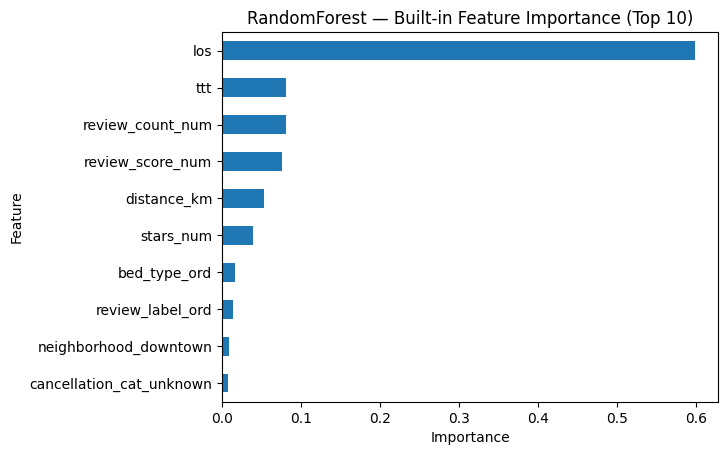

In [35]:
from sklearn.ensemble import RandomForestRegressor

rf_imp_model = RandomForestRegressor(
    n_estimators=400,
    max_depth=20,
    min_samples_leaf=3,
    max_features="sqrt",
    random_state=7,
    n_jobs=-1
)

rf_imp_model.fit(X_train, y_train)

rf_builtin = topk_importance(rf_imp_model.feature_importances_, X_train.columns, k=10)
display(rf_builtin)

plot_topk(rf_builtin, "RandomForest — Built-in Feature Importance (Top 10)")


RandomForest — Method 2: Permutation importance

los                       1.256178
ttt                       0.142213
review_score_num          0.131876
review_count_num          0.125725
stars_num                 0.105263
distance_km               0.070544
bed_type_ord              0.035687
neighborhood_downtown     0.026174
review_label_ord          0.022897
neighborhood_manhattan    0.019643
dtype: float64

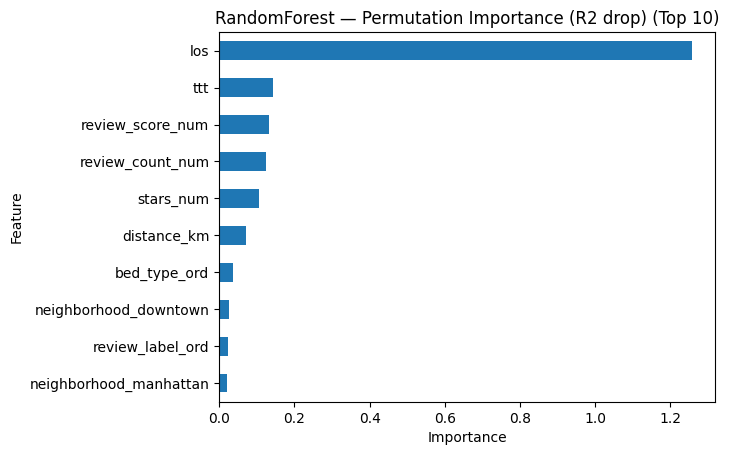

In [36]:
from sklearn.inspection import permutation_importance

perm_rf = permutation_importance(
    rf_imp_model, X_test, y_test,
    n_repeats=10,
    random_state=7,
    scoring="r2",
    n_jobs=-1
)

rf_perm = topk_importance(perm_rf.importances_mean, X_test.columns, k=10)
display(rf_perm)

plot_topk(rf_perm, "RandomForest — Permutation Importance (R2 drop) (Top 10)")


GradientBoosting — Method 1: built-in feature_importances

los                          0.660960
review_score_num             0.087763
review_count_num             0.084421
stars_num                    0.052914
ttt                          0.049641
distance_km                  0.044668
bed_type_ord                 0.006542
neighborhood_manhattan       0.004733
neighborhood_times square    0.003064
neighborhood_midtown         0.001416
dtype: float64

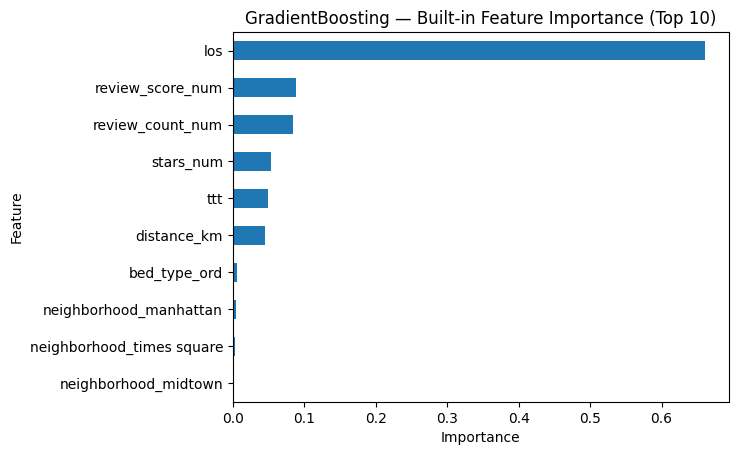

In [37]:
from sklearn.ensemble import GradientBoostingRegressor

gb_imp_model = GradientBoostingRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=3,
    random_state=7
)

gb_imp_model.fit(X_train, y_train)

gb_builtin = topk_importance(gb_imp_model.feature_importances_, X_train.columns, k=10)
display(gb_builtin)

plot_topk(gb_builtin, "GradientBoosting — Built-in Feature Importance (Top 10)")


GradientBoosting — Method 2: Permutation importance

los                          1.361693
review_count_num             0.135749
review_score_num             0.089489
ttt                          0.087868
stars_num                    0.084250
distance_km                  0.071356
bed_type_ord                 0.017707
neighborhood_manhattan       0.013313
neighborhood_times square    0.009005
neighborhood_midtown         0.004491
dtype: float64

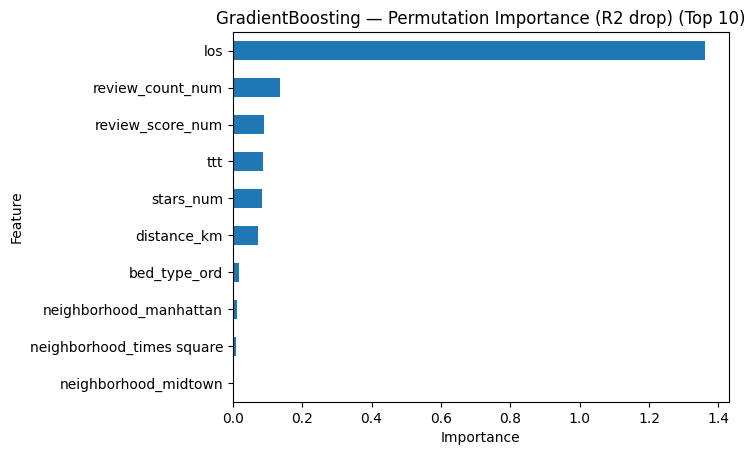

In [38]:
perm_gb = permutation_importance(
    gb_imp_model, X_test, y_test,
    n_repeats=10,
    random_state=7,
    scoring="r2",
    n_jobs=-1
)

gb_perm = topk_importance(perm_gb.importances_mean, X_test.columns, k=10)
display(gb_perm)

plot_topk(gb_perm, "GradientBoosting — Permutation Importance (R2 drop) (Top 10)")


# Task 8
In this task we evaluate the effect of different normalization/scaling methods on model performance.
We compare no scaling vs StandardScaler vs MinMaxScaler vs RobustScaler for scale-sensitive models.

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def regression_metrics(y_true, y_pred):
    r2  = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return {"R2": r2, "MAE": mae, "MSE": mse, "RMSE": rmse}

def eval_pipeline(name, pipe, X_train, y_train, X_test, y_test):
    pipe.fit(X_train, y_train)
    pred_tr = pipe.predict(X_train)
    pred_te = pipe.predict(X_test)

    m_tr = regression_metrics(y_train, pred_tr)
    m_te = regression_metrics(y_test, pred_te)

    return {
        "model": name,
        **{f"train_{k}": v for k, v in m_tr.items()},
        **{f"test_{k}": v for k, v in m_te.items()},
    }

scalers = {
    "none": None,
    "standard": StandardScaler(),
    "minmax": MinMaxScaler(),
    "robust": RobustScaler(),
}


# SVR scaling comparison

SVR is highly sensitive to feature scaling, so we compare different scalers using the same SVR hyperparameters.

In [40]:
from sklearn.svm import SVR

svr_base = SVR(C=30.0, epsilon=0.1, kernel="rbf", gamma="scale")

svr_rows = []
for scaler_name, scaler in scalers.items():
    if scaler is None:
        pipe = Pipeline([("svr", svr_base)])
    else:
        pipe = Pipeline([("scaler", scaler), ("svr", svr_base)])

    row = eval_pipeline(f"SVR_RBF__{scaler_name}", pipe, X_train, y_train, X_test, y_test)
    svr_rows.append(row)

svr_results = pd.DataFrame(svr_rows).sort_values("test_RMSE")
svr_results


,model,train_R2,train_MAE,train_MSE,train_RMSE,test_R2,test_MAE,test_MSE,test_RMSE
1,SVR_RBF__standard,0.824933,92.577551,25896.557036,160.924072,0.826765,91.843968,24970.581958,158.020828
3,SVR_RBF__robust,0.815198,94.859694,27336.652365,165.337994,0.815819,94.138902,26548.370846,162.936708
2,SVR_RBF__minmax,0.774433,108.788551,33366.754356,182.665690,0.777430,107.345222,32081.774799,179.113860
0,SVR_RBF__none,0.010250,306.663341,146407.829505,382.632761,0.012554,302.819627,142333.183459,377.270703


# KNN scaling comparison

KNN uses distance between samples, therefore scaling can drastically change performance.

In [41]:
from sklearn.neighbors import KNeighborsRegressor

knn_base = KNeighborsRegressor(n_neighbors=25, weights="distance")

knn_rows = []
for scaler_name, scaler in scalers.items():
    if scaler is None:
        pipe = Pipeline([("knn", knn_base)])
    else:
        pipe = Pipeline([("scaler", scaler), ("knn", knn_base)])

    row = eval_pipeline(f"KNN__{scaler_name}", pipe, X_train, y_train, X_test, y_test)
    knn_rows.append(row)

knn_results = pd.DataFrame(knn_rows).sort_values("test_RMSE")
knn_results


,model,train_R2,train_MAE,train_MSE,train_RMSE,test_R2,test_MAE,test_MSE,test_RMSE
3,KNN__robust,0.998986,1.547651,149.979418,12.246608,0.994004,4.696183,864.266446,29.398409
1,KNN__standard,0.998986,1.547651,149.979418,12.246608,0.993649,4.758877,915.472998,30.256784
2,KNN__minmax,0.998986,1.547651,149.979418,12.246608,0.993245,4.832268,973.618366,31.202858
0,KNN__none,0.998986,1.547651,149.979418,12.246608,0.992659,5.527092,1058.084360,32.528209


# Task 9 

We train two different neural network architectures:

A baseline MLP that uses only the engineered numeric/one-hot features.

An MLP that additionally learns an embedding vector per hotel (hotel identity), which may capture hotel-specific pricing patterns.

We evaluate both networks using R², MAE, MSE, RMSE and plot a residual plot on the test set.

In [42]:
!pip install torch

  Using cached markupsafe-3.0.3-cp310-cp310-win_amd64.whl.metadata (2.8 kB)
   ---------------------------------------- 0.0/113.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/113.7 MB ? eta -:--:--
    --------------------------------------- 2.6/113.7 MB 9.4 MB/s eta 0:00:12
   --- ------------------------------------ 8.7/113.7 MB 21.5 MB/s eta 0:00:05
   ---- ----------------------------------- 13.4/113.7 MB 19.5 MB/s eta 0:00:06
   ------- -------------------------------- 19.9/113.7 MB 22.5 MB/s eta 0:00:05
   ---------- ----------------------------- 30.7/113.7 MB 27.8 MB/s eta 0:00:03
   -------------- ------------------------- 40.6/113.7 MB 31.9 MB/s eta 0:00:03
   ------------------ --------------------- 51.6/113.7 MB 33.9 MB/s eta 0:00:02
   --------------------- ------------------ 60.3/113.7 MB 34.6 MB/s eta 0:00:02
   ----------------------- ---------------- 66.6/113.7 MB 34.0 MB/s eta 0:00:02
   ------------------------ --------------- 71.0/113.7 MB 33.1 MB


[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: C:\Users\Roni\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [43]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

Build aligned dataset with hotel_id

We rebuild a modeling table that includes:

X = all numeric/one-hot features

y = price_usd

hotel_id = integer id derived from hotel name (for embeddings)

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

assert "df_no_out" in globals(), "df_no_out not found. Run Stage B first."
assert "feature_df" in globals(), "feature_df not found. Run Stage B (feature table) first."

# We need hotel name from df_no_out and features from feature_df.
# They should be aligned by index if feature_df was created from df_no_out (as in our pipeline).
df_no_out_nn = df_no_out.copy()
feature_df_nn = feature_df.copy()

# Create a stable hotel_id from hotel name
names = df_no_out_nn["name"].fillna("UNKNOWN_HOTEL").astype(str)
hotel_to_id = {h:i for i,h in enumerate(names.unique())}
hotel_id = names.map(hotel_to_id).astype(int)

# Build X/y (from feature_df)
TARGET_COL = "price_usd"
df_model_nn = feature_df_nn.dropna(subset=[TARGET_COL]).replace([np.inf, -np.inf], np.nan).copy()

# Align hotel_id to df_model_nn index
hotel_id = hotel_id.loc[df_model_nn.index]

y_nn = df_model_nn[TARGET_COL].astype(float)
X_nn = df_model_nn.drop(columns=[TARGET_COL])

# Median imputation
imputer_nn = SimpleImputer(strategy="median")
X_nn_imp = pd.DataFrame(imputer_nn.fit_transform(X_nn), columns=X_nn.columns, index=X_nn.index)

# Train/test split (same ratio)
X_train_nn, X_test_nn, y_train_nn, y_test_nn, hid_train, hid_test = train_test_split(
    X_nn_imp, y_nn, hotel_id, test_size=0.30, random_state=7
)

print("X_train_nn:", X_train_nn.shape, "X_test_nn:", X_test_nn.shape)
print("Num hotels:", len(hotel_to_id))


X_train_nn: (30523, 15) X_test_nn: (13082, 15)
Num hotels: 250


PyTorch Dataset and DataLoaders

We convert pandas tables into tensors and create DataLoaders.

In [45]:
class HotelPriceDataset(Dataset):
    def __init__(self, X_df, y_ser, hotel_id_ser=None):
        self.X = torch.tensor(X_df.values, dtype=torch.float32)
        self.y = torch.tensor(y_ser.values, dtype=torch.float32).view(-1, 1)
        self.hotel_id = None
        if hotel_id_ser is not None:
            self.hotel_id = torch.tensor(hotel_id_ser.values, dtype=torch.long)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        if self.hotel_id is None:
            return self.X[idx], self.y[idx]
        return self.X[idx], self.hotel_id[idx], self.y[idx]

BATCH_SIZE = 256

train_ds_plain = HotelPriceDataset(X_train_nn, y_train_nn, hotel_id_ser=None)
test_ds_plain  = HotelPriceDataset(X_test_nn,  y_test_nn,  hotel_id_ser=None)

train_dl_plain = DataLoader(train_ds_plain, batch_size=BATCH_SIZE, shuffle=True)
test_dl_plain  = DataLoader(test_ds_plain,  batch_size=BATCH_SIZE, shuffle=False)

train_ds_emb = HotelPriceDataset(X_train_nn, y_train_nn, hotel_id_ser=hid_train)
test_ds_emb  = HotelPriceDataset(X_test_nn,  y_test_nn,  hotel_id_ser=hid_test)

train_dl_emb = DataLoader(train_ds_emb, batch_size=BATCH_SIZE, shuffle=True)
test_dl_emb  = DataLoader(test_ds_emb,  batch_size=BATCH_SIZE, shuffle=False)


# Baseline MLP

A simple feed-forward network over the feature vector.

In [46]:
class MLPRegressor(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x)

mlp1 = MLPRegressor(in_dim=X_train_nn.shape[1]).to(device)
mlp1


MLPRegressor(
  (net): Sequential(
    (0): Linear(in_features=15, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=128, out_features=1, bias=True)
  )
)

Training loop + evaluation utilities

We train using MSE loss and Adam optimizer, and evaluate on the test set.

In [47]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

def train_model_plain(model, train_dl, test_dl, epochs=15, lr=1e-3):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for ep in range(1, epochs+1):
        model.train()
        total = 0.0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()
            total += loss.item() * xb.size(0)

        model.eval()
        with torch.no_grad():
            preds = []
            trues = []
            for xb, yb in test_dl:
                xb = xb.to(device)
                pred = model(xb).cpu().numpy().ravel()
                preds.append(pred)
                trues.append(yb.numpy().ravel())
            preds = np.concatenate(preds)
            trues = np.concatenate(trues)

        mse = mean_squared_error(trues, preds)
        rmse = np.sqrt(mse)
        r2 = r2_score(trues, preds)
        mae = mean_absolute_error(trues, preds)
        print(f"Epoch {ep:02d} | test_R2={r2:.4f} | test_MAE={mae:.2f} | test_RMSE={rmse:.2f}")

def predict_plain(model, dl):
    model.eval()
    preds = []
    trues = []
    with torch.no_grad():
        for xb, yb in dl:
            xb = xb.to(device)
            pred = model(xb).cpu().numpy().ravel()
            preds.append(pred)
            trues.append(yb.numpy().ravel())
    return np.concatenate(trues), np.concatenate(preds)

def residual_plot_np(y_true, y_pred, title):
    resid = y_true - y_pred
    plt.figure()
    plt.scatter(y_pred, resid, s=10)
    plt.axhline(0)
    plt.title(title)
    plt.xlabel("Predicted price (USD)")
    plt.ylabel("Residual (true - pred)")
    plt.show()


In [48]:
train_model_plain(mlp1, train_dl_plain, test_dl_plain, epochs=15, lr=1e-3)

y_true_1, y_pred_1 = predict_plain(mlp1, test_dl_plain)
nn1_metrics = {
    "model": "NN1_MLP",
    "test_R2": r2_score(y_true_1, y_pred_1),
    "test_MAE": mean_absolute_error(y_true_1, y_pred_1),
    "test_MSE": mean_squared_error(y_true_1, y_pred_1),
    "test_RMSE": np.sqrt(mean_squared_error(y_true_1, y_pred_1)),
}
nn1_metrics


Epoch 01 | test_R2=-1.0246 | test_MAE=418.78 | test_RMSE=540.21
Epoch 02 | test_R2=0.0624 | test_MAE=297.39 | test_RMSE=367.62
Epoch 03 | test_R2=0.0686 | test_MAE=290.32 | test_RMSE=366.41
Epoch 04 | test_R2=0.0671 | test_MAE=289.06 | test_RMSE=366.70
Epoch 05 | test_R2=0.1190 | test_MAE=279.67 | test_RMSE=356.36
Epoch 06 | test_R2=0.2690 | test_MAE=251.33 | test_RMSE=324.61
Epoch 07 | test_R2=0.4335 | test_MAE=231.51 | test_RMSE=285.76
Epoch 08 | test_R2=0.4794 | test_MAE=214.05 | test_RMSE=273.93
Epoch 09 | test_R2=0.5291 | test_MAE=198.60 | test_RMSE=260.53
Epoch 10 | test_R2=0.4756 | test_MAE=200.83 | test_RMSE=274.94
Epoch 11 | test_R2=0.5229 | test_MAE=189.82 | test_RMSE=262.23
Epoch 12 | test_R2=0.6403 | test_MAE=168.17 | test_RMSE=227.72
Epoch 13 | test_R2=0.5981 | test_MAE=198.14 | test_RMSE=240.70
Epoch 14 | test_R2=0.4759 | test_MAE=198.49 | test_RMSE=274.86
Epoch 15 | test_R2=0.6607 | test_MAE=166.14 | test_RMSE=221.16


{'model': 'NN1_MLP',
 'test_R2': 0.6606578826904297,
 'test_MAE': 166.14356994628906,
 'test_MSE': 48913.69140625,
 'test_RMSE': np.float64(221.16439904797065)}

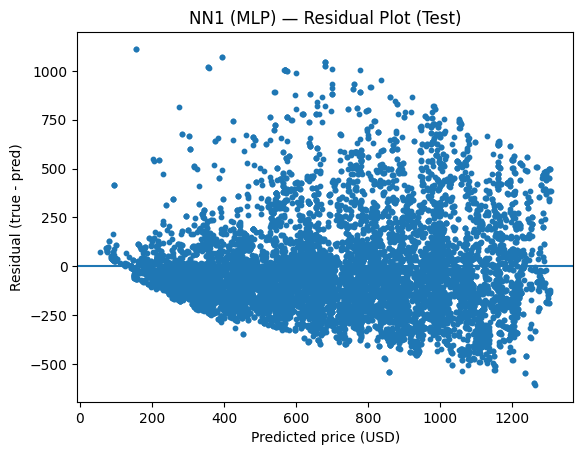

In [49]:
residual_plot_np(y_true_1, y_pred_1, "NN1 (MLP) — Residual Plot (Test)")


# MLP with hotel embedding

This model learns a vector representation for each hotel (hotel_id) and concatenates it with the feature vector.

In [50]:
class MLPWithHotelEmbedding(nn.Module):
    def __init__(self, in_dim, num_hotels, emb_dim=16):
        super().__init__()
        self.emb = nn.Embedding(num_hotels, emb_dim)

        self.net = nn.Sequential(
            nn.Linear(in_dim + emb_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 1)
        )

    def forward(self, x, hotel_id):
        e = self.emb(hotel_id)
        z = torch.cat([x, e], dim=1)
        return self.net(z)

mlp2 = MLPWithHotelEmbedding(
    in_dim=X_train_nn.shape[1],
    num_hotels=len(hotel_to_id),
    emb_dim=16
).to(device)
mlp2


MLPWithHotelEmbedding(
  (emb): Embedding(250, 16)
  (net): Sequential(
    (0): Linear(in_features=31, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [51]:
def train_model_emb(model, train_dl, test_dl, epochs=15, lr=1e-3):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for ep in range(1, epochs+1):
        model.train()
        total = 0.0
        for xb, hid, yb in train_dl:
            xb, hid, yb = xb.to(device), hid.to(device), yb.to(device)
            opt.zero_grad()
            pred = model(xb, hid)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()
            total += loss.item() * xb.size(0)

        model.eval()
        with torch.no_grad():
            preds = []
            trues = []
            for xb, hid, yb in test_dl:
                xb, hid = xb.to(device), hid.to(device)
                pred = model(xb, hid).cpu().numpy().ravel()
                preds.append(pred)
                trues.append(yb.numpy().ravel())
            preds = np.concatenate(preds)
            trues = np.concatenate(trues)

        mse = mean_squared_error(trues, preds)
        rmse = np.sqrt(mse)
        r2 = r2_score(trues, preds)
        mae = mean_absolute_error(trues, preds)
        print(f"Epoch {ep:02d} | test_R2={r2:.4f} | test_MAE={mae:.2f} | test_RMSE={rmse:.2f}")

def predict_emb(model, dl):
    model.eval()
    preds = []
    trues = []
    with torch.no_grad():
        for xb, hid, yb in dl:
            xb, hid = xb.to(device), hid.to(device)
            pred = model(xb, hid).cpu().numpy().ravel()
            preds.append(pred)
            trues.append(yb.numpy().ravel())
    return np.concatenate(trues), np.concatenate(preds)


In [52]:
train_model_emb(mlp2, train_dl_emb, test_dl_emb, epochs=15, lr=1e-3)

y_true_2, y_pred_2 = predict_emb(mlp2, test_dl_emb)
nn2_metrics = {
    "model": "NN2_MLP+HotelEmbedding",
    "test_R2": r2_score(y_true_2, y_pred_2),
    "test_MAE": mean_absolute_error(y_true_2, y_pred_2),
    "test_MSE": mean_squared_error(y_true_2, y_pred_2),
    "test_RMSE": np.sqrt(mean_squared_error(y_true_2, y_pred_2)),
}
nn2_metrics


Epoch 01 | test_R2=-0.5028 | test_MAE=359.64 | test_RMSE=465.42
Epoch 02 | test_R2=0.1209 | test_MAE=281.17 | test_RMSE=355.96
Epoch 03 | test_R2=0.2727 | test_MAE=253.93 | test_RMSE=323.79
Epoch 04 | test_R2=0.4332 | test_MAE=227.65 | test_RMSE=285.84
Epoch 05 | test_R2=0.3816 | test_MAE=244.53 | test_RMSE=298.57
Epoch 06 | test_R2=0.5810 | test_MAE=182.73 | test_RMSE=245.75
Epoch 07 | test_R2=0.5484 | test_MAE=184.48 | test_RMSE=255.14
Epoch 08 | test_R2=0.7255 | test_MAE=154.49 | test_RMSE=198.92
Epoch 09 | test_R2=0.7671 | test_MAE=122.84 | test_RMSE=183.23
Epoch 10 | test_R2=0.7737 | test_MAE=121.70 | test_RMSE=180.62
Epoch 11 | test_R2=0.8171 | test_MAE=116.41 | test_RMSE=162.38
Epoch 12 | test_R2=0.8098 | test_MAE=107.81 | test_RMSE=165.59
Epoch 13 | test_R2=0.7555 | test_MAE=125.74 | test_RMSE=187.75
Epoch 14 | test_R2=0.8358 | test_MAE=105.41 | test_RMSE=153.84
Epoch 15 | test_R2=0.8330 | test_MAE=108.85 | test_RMSE=155.14


{'model': 'NN2_MLP+HotelEmbedding',
 'test_R2': 0.8330180644989014,
 'test_MAE': 108.85025024414062,
 'test_MSE': 24069.23046875,
 'test_RMSE': np.float64(155.1426133231937)}

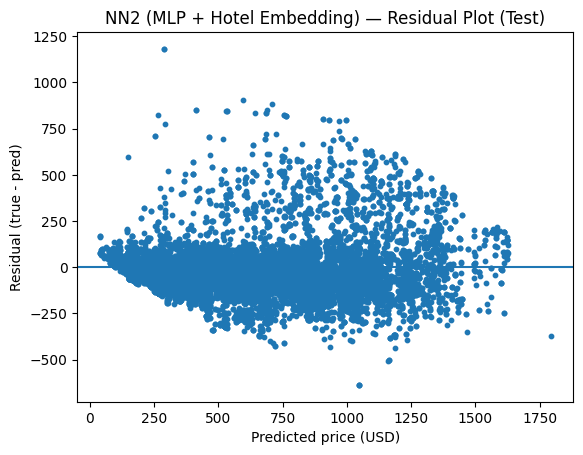

In [53]:
residual_plot_np(y_true_2, y_pred_2, "NN2 (MLP + Hotel Embedding) — Residual Plot (Test)")


We compare NN1 vs NN2 on the same test set.

In [54]:
pd.DataFrame([nn1_metrics, nn2_metrics])

,model,test_R2,test_MAE,test_MSE,test_RMSE
0,NN1_MLP,0.660658,166.14357,48913.691406,221.164399
1,NN2_MLP+HotelEmbedding,0.833018,108.85025,24069.230469,155.142613
